## In this notebook, we will preprocess the images by taking out images we don't need and by cropping the images to improve the model performance


In [1]:
import pandas as pd
import os
import shutil

# ── Step 1 — Load and filter the CSV ──────────────────────────
combined_df = pd.read_csv("../data/combined_df.csv")

VALID_SUBCATEGORIES = ['Tops', 'Bottomwear', 'Shoes', 'Dress', 'Outerwear']

combined_df = combined_df[combined_df["subCategory"].isin(VALID_SUBCATEGORIES)].reset_index(drop=True)

print(f"Rows after filtering: {len(combined_df)}")
print(combined_df["subCategory"].value_counts())

Rows after filtering: 23393
subCategory
Tops          12776
Shoes          7321
Bottomwear     2537
Dress           480
Outerwear       279
Name: count, dtype: int64


In [2]:
# ── Step 2 — Copy only the images we need to a new folder ─────
RAW_IMAGE_DIR      = "../data/images/raw_images"       # where all downloaded images are
FILTERED_IMAGE_DIR = "../data/images/filtered_images"  # where we'll copy the ones we need

os.makedirs(FILTERED_IMAGE_DIR, exist_ok=True)

kept    = 0
skipped = 0
missing = 0

for _, row in combined_df.iterrows():
    filename = row["filename"]                                    # e.g. "15970.jpg"
    src      = os.path.join(RAW_IMAGE_DIR, filename)
    dst      = os.path.join(FILTERED_IMAGE_DIR, filename)

    if os.path.exists(dst):
        skipped += 1
        continue

    if not os.path.exists(src):
        print(f"Missing: {filename}")
        missing += 1
        continue

    shutil.copy2(src, dst)
    kept += 1

print(f"\nDone. Kept: {kept} | Already existed: {skipped} | Missing: {missing}")

Missing: 39403.jpg
Missing: 39410.jpg
Missing: 39401.jpg
Missing: 39425.jpg
Missing: 12347.jpg

Done. Kept: 23388 | Already existed: 0 | Missing: 5


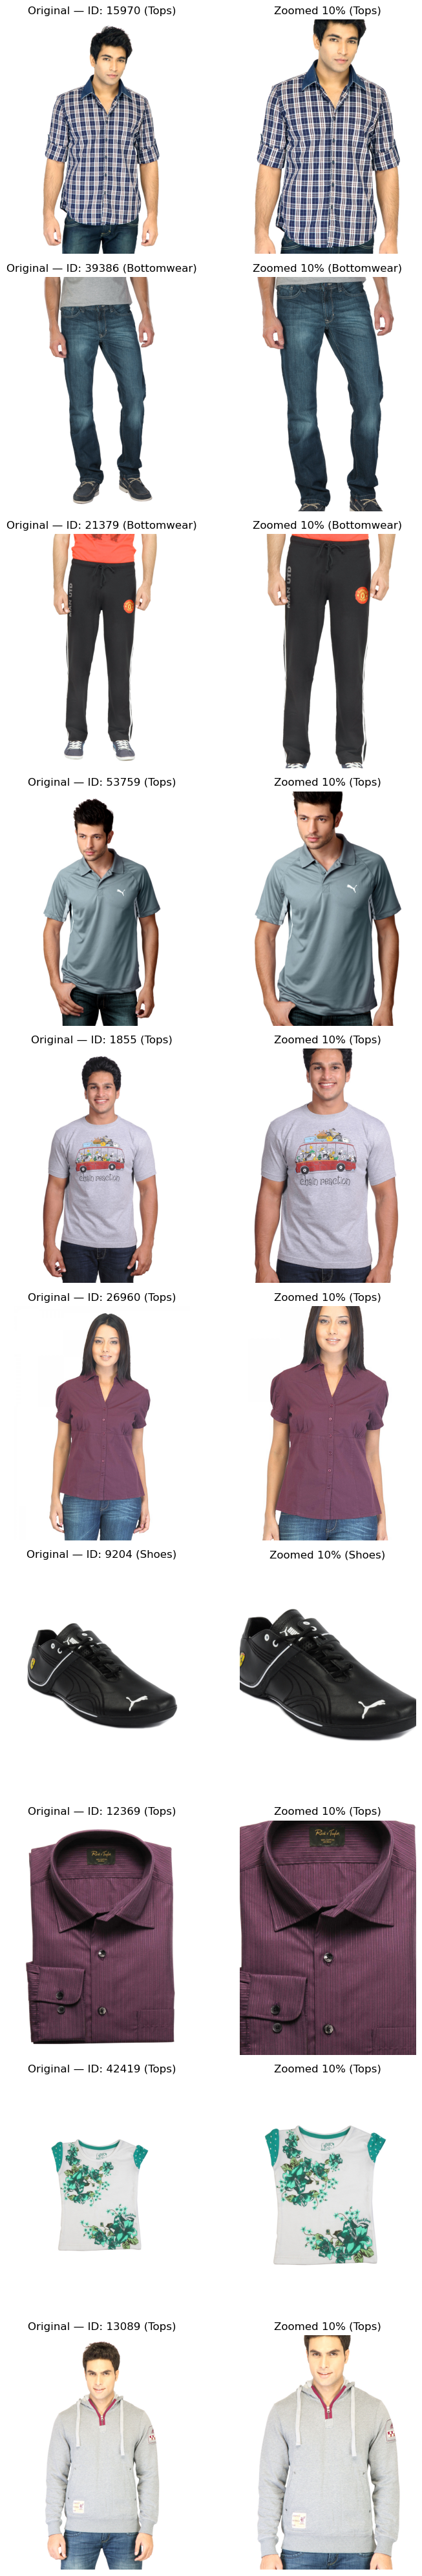

In [ ]:
import sys, os
sys.path.append(os.path.abspath(".."))
from scripts.crop_clothing import preview_crop_from_df, batch_crop_from_df

RAW_IMAGE_DIR = "../data/images/filtered_images"
OUTPUT_DIR    = "../data/images/processed_images"

# Step 1 — preview first
preview_crop_from_df(combined_df, raw_image_dir=RAW_IMAGE_DIR, n=10)


In [4]:
# Step 2 — run on full dataset once happy with the preview
batch_crop_from_df(combined_df, raw_image_dir=RAW_IMAGE_DIR, output_dir=OUTPUT_DIR)

File not found: ../data/images/filtered_images/39403.jpg
File not found: ../data/images/filtered_images/39410.jpg
File not found: ../data/images/filtered_images/39401.jpg
File not found: ../data/images/filtered_images/39425.jpg
File not found: ../data/images/filtered_images/12347.jpg

Done. Success: 23388 | Skipped: 0 | Failed: 5
